# Загружаю данные и смотрю на них

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import find_peaks

In [ ]:
df = pd.read_csv('26_w.csv', sep=';', encoding='cp1251')

In [ ]:
print(f"Строк: {len(df)}")
print(f"Колонок: {len(df.columns)}")

Строк: 232
Колонок: 60


In [ ]:
df.head()

,Unnamed: 0,len,Скорость,Широта,Долгота,Вес мгновенный,Продольный наклон,Поперечный наклон,Высота,"Уровень топлива, литры",...,"уровень давления сзади,МПа",рекомендованная скорость_turns,Поворот влево,Поворот вправо,centr,radius,подъем,спуск,рекомендованная скорость_min,рекомендованная скорость_max
0,0,0.0,6.0,53.727769,86.853734,213.0,-1.844064,-3.064920,-0.754789,NaN,...,9.9,0.0,0,0,-,0.0,0,0,0.0,0.0
1,1,7.0,7.0,53.727741,86.853833,210.0,-2.286488,-2.238432,-0.371648,NaN,...,9.9,0.0,0,0,-,0.0,0,0,0.0,0.0
2,2,15.0,8.0,53.727718,86.853938,209.0,-3.123734,-1.603393,-0.080931,NaN,...,9.9,0.0,0,0,-,0.0,0,0,0.0,0.0
3,3,25.0,5.0,53.727689,86.854089,210.0,-5.758232,-1.142521,0.124609,NaN,...,9.9,0.0,0,0,-,0.0,0,0,0.0,0.0
4,4,29.0,10.0,53.727672,86.854149,219.0,6.025384,-0.838536,0.252225,NaN,...,9.9,0.0,0,0,-,0.0,0,0,0.0,0.0


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
"Уровень топлива, литры",232


# Расчет продольного и поперечного наклона

In [ ]:
# Рассчитываем продольный наклон
df['Продольный_наклон'] = np.arctan2(
    -df['Ускорение по оси Z'],
    np.sqrt(df['Ускорение по оси X']**2 + df['Ускорение по оси Y']**2)
) * 180 / np.pi

# Рассчитываем поперечный наклон
df['Поперечный_наклон'] = np.arctan2(
    -df['Ускорение по оси X'],
    np.sqrt(df['Ускорение по оси Z']**2 + df['Ускорение по оси Y']**2)
) * 180 / np.pi

In [ ]:
print(f"Продольный наклон: min={df['Продольный_наклон'].min():.2f}°, max={df['Продольный_наклон'].max():.2f}°")

Продольный наклон: min=-5.76°, max=7.44°


In [ ]:
print(f"Поперечный наклон: min={df['Поперечный_наклон'].min():.2f}°, max={df['Поперечный_наклон'].max():.2f}°")

Поперечный наклон: min=-4.05°, max=8.28°


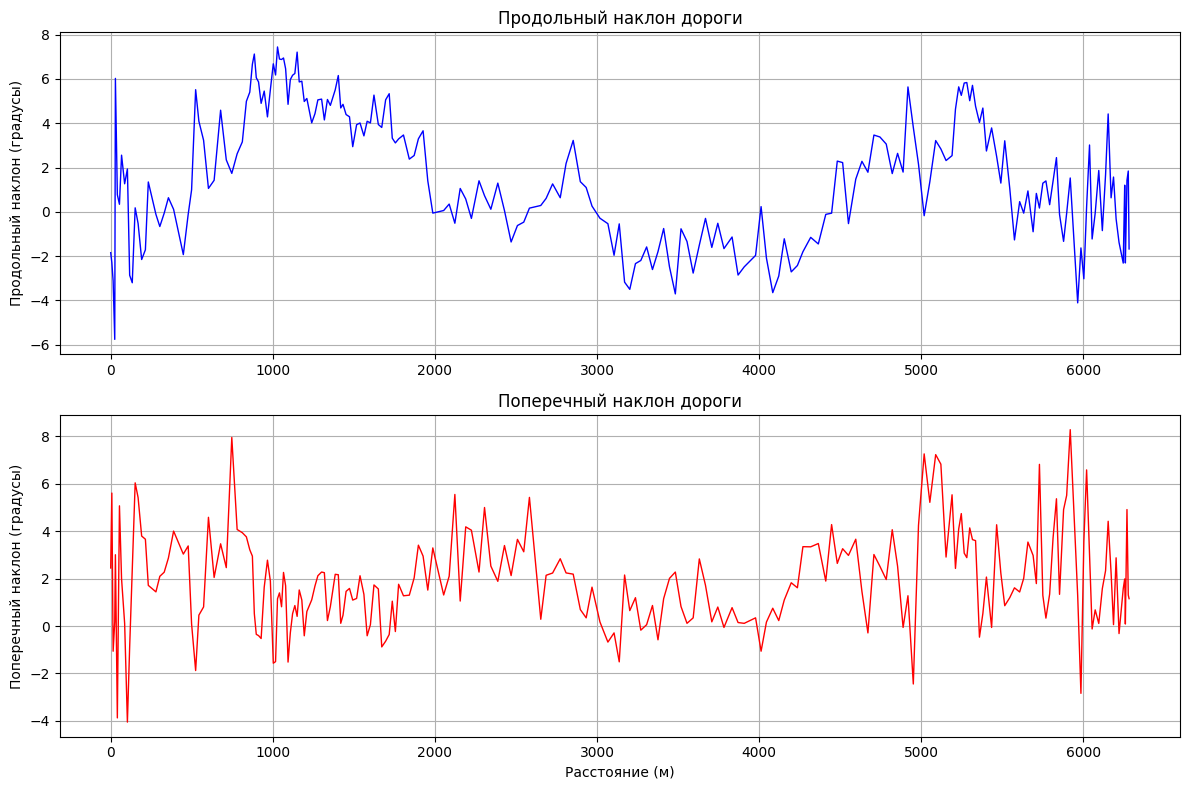

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(df['len'], df['Продольный_наклон'], 'b-', linewidth=1)
axes[0].set_ylabel('Продольный наклон (градусы)')
axes[0].set_title('Продольный наклон дороги')
axes[0].grid(True)

axes[1].plot(df['len'], df['Поперечный_наклон'], 'r-', linewidth=1)
axes[1].set_xlabel('Расстояние (м)')
axes[1].set_ylabel('Поперечный наклон (градусы)')
axes[1].set_title('Поперечный наклон дороги')
axes[1].grid(True)

plt.tight_layout()
plt.show()

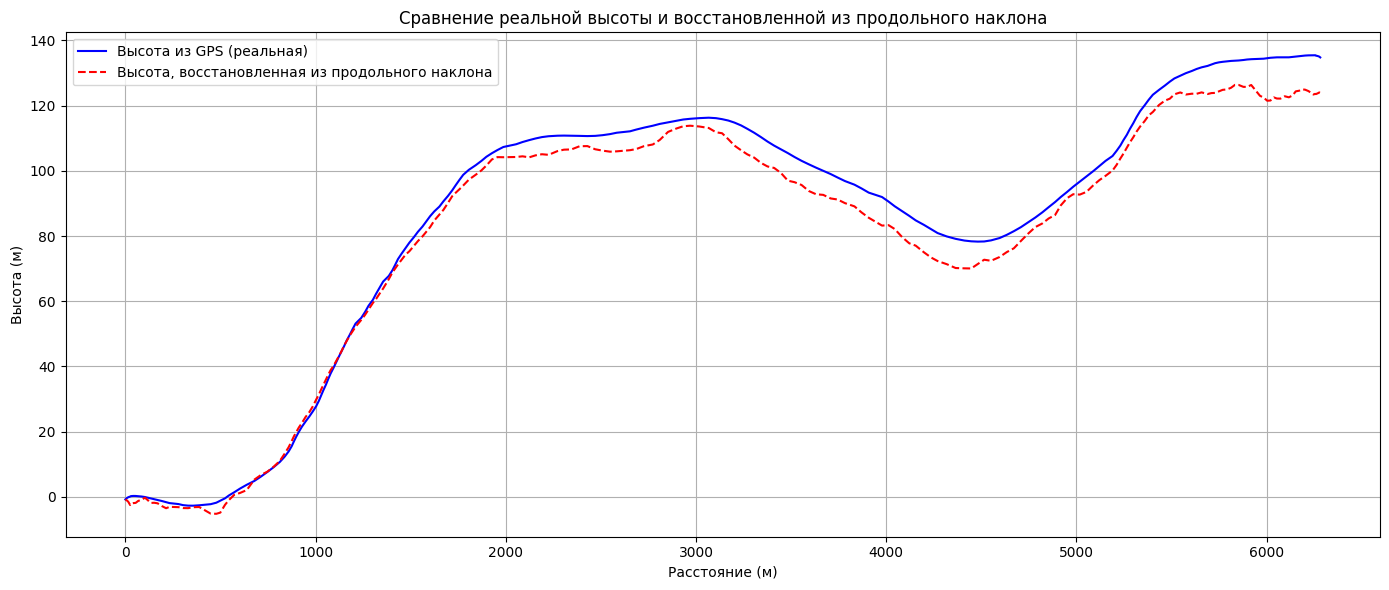

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Переводим наклон из градусов в радианы
slope_rad = np.radians(df['Продольный_наклон'])


delta_len = df['len'].diff().fillna(0)

# ΔH = Δlen * tan(угла)
delta_height = delta_len * np.tan(slope_rad)

df['Высота_восстановленная'] = delta_height.cumsum()

offset = df['Высота'].iloc[0] - df['Высота_восстановленная'].iloc[0]
df['Высота_восстановленная'] = df['Высота_восстановленная'] + offset


plt.figure(figsize=(14, 6))
plt.plot(df['len'], df['Высота'], 'b-', linewidth=1.5, label='Высота из GPS (реальная)')
plt.plot(df['len'], df['Высота_восстановленная'], 'r--', linewidth=1.5, label='Высота, восстановленная из продольного наклона')
plt.xlabel('Расстояние (м)')
plt.ylabel('Высота (м)')
plt.title('Сравнение реальной высоты и восстановленной из продольного наклона')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# Анализ давления в подвеске

In [ ]:
pressure_cols = [col for col in df.columns if 'Давление' in col and 'цилиндр' in col]
print("Колонки с давлением в подвеске")
for col in pressure_cols:
    print(f"  - {col}")

Колонки с давлением в подвеске
  - Давление левый передний цилиндр
  - Давление правый передний цилиндр
  - Давление левый задний цилиндр
  - Давление правый задний цилиндр
  - Давление левый передний цилиндр_
  - Давление правый передний цилиндр_
  - Давление левый задний цилиндр_
  - Давление правый задний цилиндр_


In [ ]:
pressure_cols = pressure_cols[:4]

In [ ]:
for col in pressure_cols:
    print(f"{col}: min={df[col].min():.1f}, max={df[col].max():.1f}, mean={df[col].mean():.1f}")

Давление левый передний цилиндр: min=3.6, max=10.5, mean=6.2
Давление правый передний цилиндр: min=4.2, max=11.5, mean=6.9
Давление левый задний цилиндр: min=6.7, max=15.5, mean=9.7
Давление правый задний цилиндр: min=7.6, max=15.6, mean=10.6


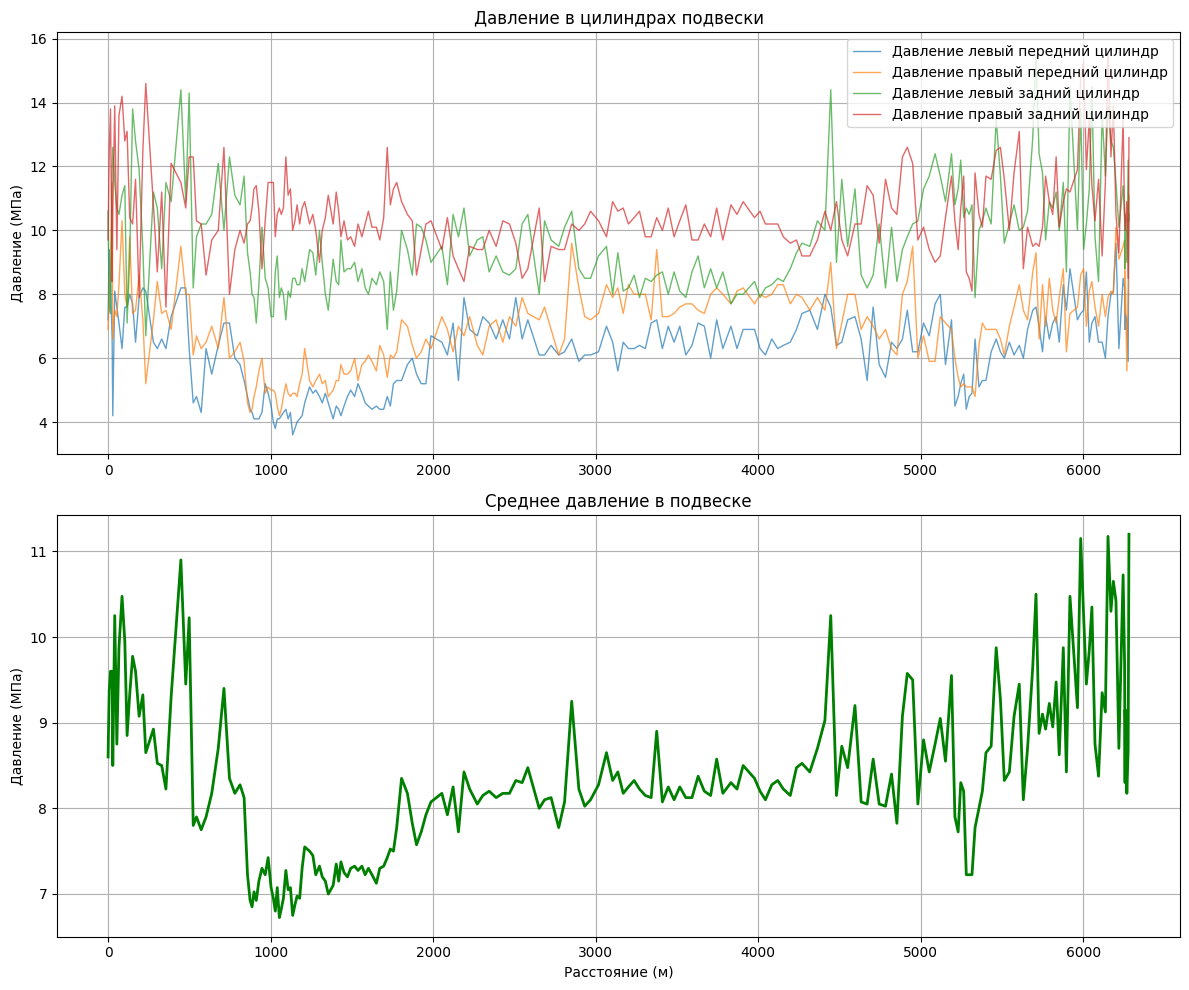

In [ ]:
df['Давление_среднее'] = df[pressure_cols].mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for col in pressure_cols:
    axes[0].plot(df['len'], df[col], label=col, alpha=0.7, linewidth=1)
axes[0].set_ylabel('Давление (МПа)')
axes[0].set_title('Давление в цилиндрах подвески')
axes[0].legend(loc='upper right')
axes[0].grid(True)


axes[1].plot(df['len'], df['Давление_среднее'], 'g-', linewidth=2)
axes[1].set_xlabel('Расстояние (м)')
axes[1].set_ylabel('Давление (МПа)')
axes[1].set_title('Среднее давление в подвеске')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
signal_original = df[pressure_cols].mean(axis=1).values

# Профиль дороги, FFT фильтрация

In [ ]:
def fft_filter_potholes(signal, fs=1.0, low_cut=0.02, high_cut=0.15):
    """
    FFT-фильтр для выделения ям из сигнала давления

    Параметры:
    - signal: исходный сигнал (давление)
    - fs: частота дискретизации (1 = одна точка = 1 метр или 1 секунда)
    - low_cut: нижняя граница частот (убираем частоты ниже этого значения = профиль дороги)
    - high_cut: верхняя граница частот (убираем частоты выше = шум)

    Возвращает:
    - filtered_signal: очищенный сигнал (только аномалии = потенциальные ямы)
    """
    n = len(signal)

    signal_detrended = signal - np.mean(signal)

    fft_vals = fft(signal_detrended)
    frequencies = fftfreq(n, 1/fs)

    mask = (np.abs(frequencies) >= low_cut) & (np.abs(frequencies) <= high_cut)

    fft_filtered = fft_vals * mask

    signal_filtered = np.real(ifft(fft_filtered))

    return signal_filtered, frequencies, np.abs(fft_vals), mask


signal_filtered, freqs, fft_magnitude, mask = fft_filter_potholes(
    signal_original,
    fs=1.0,
    low_cut=0.02,
    high_cut=0.15
)

df['Аномалия_давления_FFT'] = signal_filtered

print("FFT-фильтрация выполнена")

FFT-фильтрация выполнена


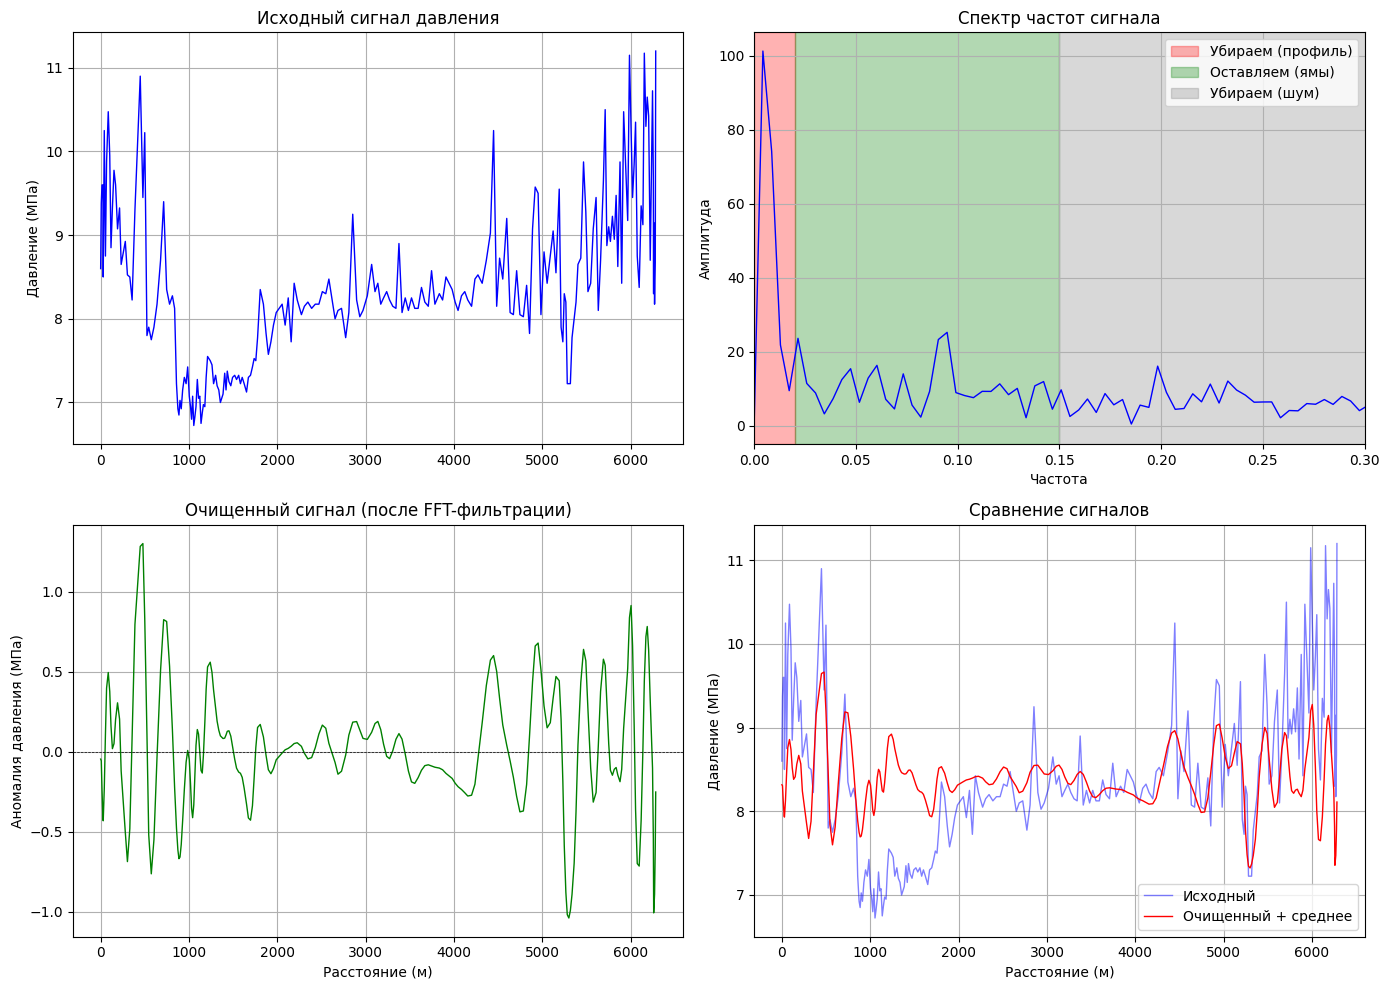

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Исходный сигнал
axes[0, 0].plot(df['len'], signal_original, 'b-', linewidth=1)
axes[0, 0].set_title('Исходный сигнал давления')
axes[0, 0].set_ylabel('Давление (МПа)')
axes[0, 0].grid(True)

# 2. Спектр частот (что мы видим после FFT)
axes[0, 1].plot(freqs[freqs >= 0], fft_magnitude[freqs >= 0], 'b-', linewidth=1)
axes[0, 1].axvspan(0, 0.02, alpha=0.3, color='red', label='Убираем (профиль)')
axes[0, 1].axvspan(0.02, 0.15, alpha=0.3, color='green', label='Оставляем (ямы)')
axes[0, 1].axvspan(0.15, max(freqs[freqs >= 0]), alpha=0.3, color='gray', label='Убираем (шум)')
axes[0, 1].set_xlim(0, 0.3)
axes[0, 1].set_title('Спектр частот сигнала')
axes[0, 1].set_xlabel('Частота')
axes[0, 1].set_ylabel('Амплитуда')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Очищенный сигнал (только аномалии)
axes[1, 0].plot(df['len'], signal_filtered, 'g-', linewidth=1)
axes[1, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
axes[1, 0].set_title('Очищенный сигнал (после FFT-фильтрации)')
axes[1, 0].set_xlabel('Расстояние (м)')
axes[1, 0].set_ylabel('Аномалия давления (МПа)')
axes[1, 0].grid(True)

# 4. Сравнение исходного и очищенного
axes[1, 1].plot(df['len'], signal_original, 'b-', alpha=0.5, linewidth=1, label='Исходный')
axes[1, 1].plot(df['len'], signal_filtered + np.mean(signal_original), 'r-', linewidth=1, label='Очищенный + среднее')
axes[1, 1].set_title('Сравнение сигналов')
axes[1, 1].set_xlabel('Расстояние (м)')
axes[1, 1].set_ylabel('Давление (МПа)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Поиск ям

Найдено ям: 6
Яма на 303 м: аномалия=-0.69 МПа, координаты=53.726833, 86.852260
Яма на 573 м: аномалия=-0.76 МПа, координаты=53.728907, 86.850161
Яма на 886 м: аномалия=-0.67 МПа, координаты=53.731609, 86.849279
Яма на 5299 м: аномалия=-1.04 МПа, координаты=53.757955, 86.854608
Яма на 6095 м: аномалия=-0.72 МПа, координаты=53.754339, 86.864482
Яма на 6259 м: аномалия=-1.01 МПа, координаты=53.753691, 86.865883


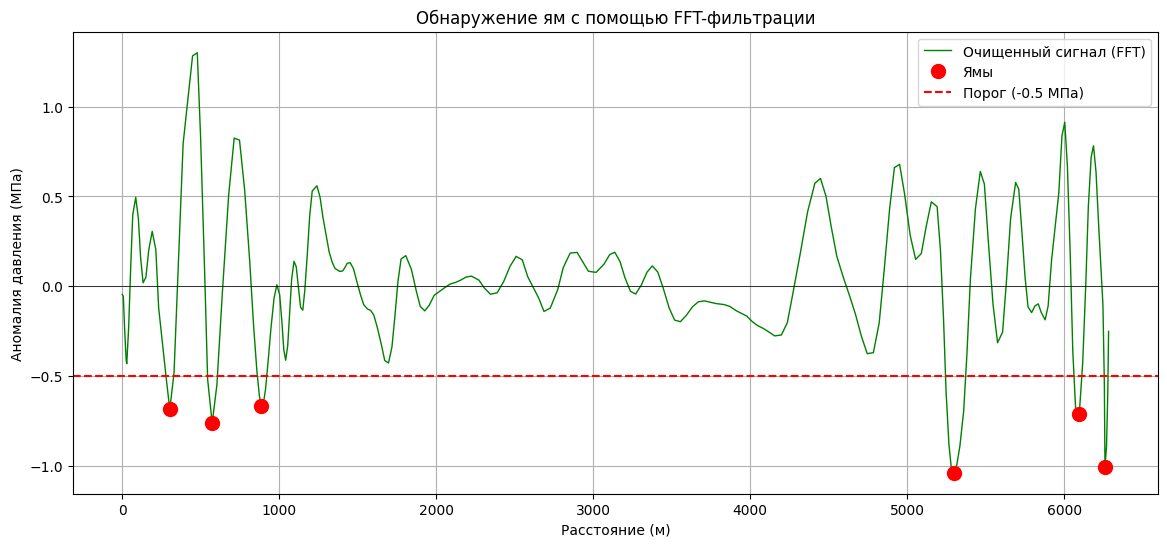

In [ ]:
threshold = 0.5
min_distance = 7

# Ищем отрицательные пики (падения давления)
# В очищенном сигнале яма = отрицательное значение
peaks, properties = find_peaks(
    -signal_filtered,
    height=threshold,
    distance=min_distance,
    prominence=0.3
)


df['is_hole'] = False
df.loc[peaks, 'is_hole'] = True

holes = df[df['is_hole']].copy()
print(f"Найдено ям: {len(holes)}")


for idx, row in holes.iterrows():
    print(f"Яма на {row['len']:.0f} м: аномалия={row['Аномалия_давления_FFT']:.2f} МПа, "
          f"координаты={row['Широта']:.6f}, {row['Долгота']:.6f}")


plt.figure(figsize=(14, 6))
plt.plot(df['len'], signal_filtered, 'g-', linewidth=1, label='Очищенный сигнал (FFT)')
plt.plot(holes['len'], holes['Аномалия_давления_FFT'], 'ro', markersize=10, label='Ямы')
plt.axhline(y=-threshold, color='r', linestyle='--', label=f'Порог (-{threshold} МПа)')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.xlabel('Расстояние (м)')
plt.ylabel('Аномалия давления (МПа)')
plt.title('Обнаружение ям с помощью FFT-фильтрации')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
fig = go.Figure()

# Маршрут
fig.add_trace(go.Scattermap(
    lat=df['Широта'],
    lon=df['Долгота'],
    mode='lines',
    line=dict(width=4, color='blue'),
    name='Маршрут'
))

# Ямы
fig.add_trace(go.Scattermap(
    lat=holes['Широта'],
    lon=holes['Долгота'],
    mode='markers',
    marker=dict(size=14, color='red', symbol='circle'),
    text=[f"Яма #{i}<br>Аномалия: {abs(row['Аномалия_давления_FFT']):.1f} МПа<br>Расстояние: {row['len']:.0f} м"
          for i, row in holes.iterrows()],
    name='Ямы',
    hovertemplate='%{text}<extra></extra>'
))

# Настройки
fig.update_layout(
    title='Обнаружение ям на маршруте самосвала (FFT-фильтрация)',
    map=dict(
        style='open-street-map',
        center=dict(lat=df['Широта'].mean(), lon=df['Долгота'].mean()),
        zoom=14
    ),
    height=700
)

fig.show()
fig.write_html('map_with_holes_fft.html')

In [ ]:
df['is_hole']

,is_hole
0,False
1,False
2,False
3,False
4,False
...,...
227,False
228,True
229,False
230,False


In [ ]:
df[df['is_hole'] == True]

,Unnamed: 0,len,Скорость,Широта,Долгота,Вес мгновенный,Продольный наклон,Поперечный наклон,Высота,"Уровень топлива, литры",...,radius,подъем,спуск,рекомендованная скорость_min,рекомендованная скорость_max,Продольный_наклон,Поперечный_наклон,Давление_среднее,Аномалия_давления_FFT,is_hole
18,18,303.0,21.0,53.726833,86.852260,214.0,-0.662543,-2.605419,-2.508046,NaN,...,0.0,0,0,0.0,0.0,-0.662543,2.098477,8.525,-0.687673,True
27,27,573.0,21.0,53.728907,86.850161,219.0,3.230689,-2.747533,1.464368,NaN,...,0.0,0,0,0.0,0.0,3.230689,0.807271,7.750,-0.764019,True
38,38,886.0,11.0,53.731609,86.849279,219.0,7.124717,-2.262517,17.033716,NaN,...,0.0,0,0,0.0,0.0,7.124717,0.524248,6.850,-0.669290,True
183,183,5299.0,14.0,53.757955,86.854608,219.0,5.017307,-3.322691,114.586207,NaN,...,0.0,0,0,0.0,0.0,5.017307,4.140506,7.225,-1.040207,True
217,217,6095.0,18.0,53.754339,86.864482,216.0,1.868281,-1.876333,134.795402,NaN,...,0.0,0,0,0.0,0.0,1.868281,0.111519,8.375,-0.715531,True
228,228,6259.0,3.0,53.753691,86.865883,216.5,-2.306737,-1.642034,135.295377,NaN,...,0.0,0,0,0.0,0.0,-2.306737,0.086479,9.150,-1.008350,True
